In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sentence_transformers import SentenceTransformer


In [2]:
data = pd.read_csv('/Users/huseyinbilgili/Desktop/Graduation project/data/final_data.csv')

In [11]:
data.head()

,id,original_id,category,source_type,degradation_level,expected_quality_class,whole_text,final_quality_score
0,2,2,Finansal Hizmetler,original,none,Good,"representative: Merhaba, size nasıl yardımcı o...",56.50
1,3,3,Finansal Hizmetler,original,none,Good,"customer: Merhaba, BP monitörü satın almaya ça...",82.00
2,4,4,Finansal Hizmetler,original,none,Good,"customer: Merhaba, son siparişimde bir fatura ...",92.25
3,5,5,Finansal Hizmetler,original,none,Good,"representative: Merhaba, benim adım John. Size...",86.75
4,6,6,Finansal Hizmetler,original,none,Good,"customer: Merhaba, BrownBox'tan aldığım telefo...",90.25


In [12]:
data.columns

Index(['id', 'original_id', 'category', 'source_type', 'degradation_level',
       'expected_quality_class', 'whole_text', 'final_quality_score'],
      dtype='str')

In [14]:
data['final_quality_score'] = data['final_quality_score'].astype(float)

In [15]:
def score_to_class(score):
    if score >= 85:
        return "excellent"
    elif score >= 70:
        return "good"
    elif score >= 55:
        return "average"
    else:
        return "poor"

data['quality_class'] = data['final_quality_score'].apply(score_to_class)


In [16]:
data

,id,original_id,category,source_type,degradation_level,expected_quality_class,whole_text,final_quality_score,quality_class
0,2,2,Finansal Hizmetler,original,none,Good,"representative: Merhaba, size nasıl yardımcı o...",56.50,average
1,3,3,Finansal Hizmetler,original,none,Good,"customer: Merhaba, BP monitörü satın almaya ça...",82.00,good
2,4,4,Finansal Hizmetler,original,none,Good,"customer: Merhaba, son siparişimde bir fatura ...",92.25,excellent
3,5,5,Finansal Hizmetler,original,none,Good,"representative: Merhaba, benim adım John. Size...",86.75,excellent
4,6,6,Finansal Hizmetler,original,none,Good,"customer: Merhaba, BrownBox'tan aldığım telefo...",90.25,excellent
...,...,...,...,...,...,...,...,...,...
2690,4099,278,Finansal Hizmetler,synthetic,poor,poor,"customer: Merhaba, ödeme yaptıktan sonra hala ...",35.00,poor
2691,4100,2601,İade ve Değişim,synthetic,poor,poor,"customer: Merhaba, Lenovo ThinkPad X1 Carbon'u...",0.00,poor
2692,4101,2593,İade ve Değişim,synthetic,poor,poor,"customer: Merhaba, Asus VivoBook bilgisayarımı...",10.50,poor
2693,4102,2021,İade ve Değişim,synthetic,poor,poor,"customer: Merhaba, iade etmek istediğim hasarl...",0.00,poor


In [17]:
pd.set_option("display.max_colwidth", 60)

data.drop('expected_quality_class',axis=1,inplace=True)


In [18]:
data["final_quality_score"].describe()

count    2695.000000
mean       55.402134
std        28.113206
min         0.000000
25%        33.500000
50%        61.000000
75%        78.500000
max       100.000000
Name: final_quality_score, dtype: float64

<Axes: xlabel='final_quality_score', ylabel='Count'>

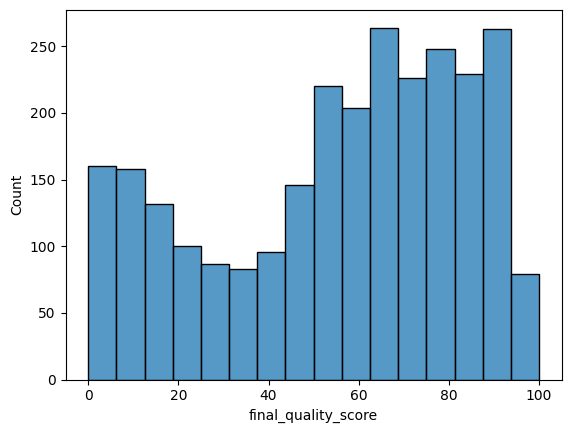

In [19]:
sns.histplot(data=data, x='final_quality_score')

In [23]:
X=data[['whole_text','original_id']]
y=data['final_quality_score']

X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=17,shuffle=True,stratify=data['quality_class'])

aug_df= pd.read_csv(f'/Users/huseyinbilgili/Desktop/Graduation project/data/augmented_training_data.csv')
aug_df = aug_df[aug_df['base_original_id'].isin(X_train['original_id'])]
X_train= pd.concat([X_train['whole_text'],aug_df['whole_text']],axis=0,ignore_index=True)
y_train= pd.concat([y_train,aug_df['final_quality_score']],axis=0,ignore_index=True)
X_test=X_test['whole_text']
print(X_train.shape,y_train.shape)

(2666,) (2666,)


In [24]:
baseline_model = Pipeline([
    ('tfidf',
     TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    lowercase=True
        )
    ),(
    'regressor',Ridge(alpha=1.0)
    )
])

In [25]:
baseline_model.fit(X_train,y_train)

baseline_preds = baseline_model.predict(X_test)

def evaluation(y_true, y_pred,model_name):
    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    r2=r2_score(y_true,y_pred)

    print(f"\n{model_name}")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))

    return {
        'model': model_name,
        'mae' : mae,
        'rmse':rmse,
        'r2':r2
    }

In [26]:
results = evaluation(y_test,baseline_preds,'TF-IDF + Ridge Regressor')


TF-IDF + Ridge Regressor
MAE : 10.5215
RMSE: 13.9012
R2  : 0.7702


In [27]:
tfidf = baseline_model.named_steps["tfidf"]
ridge = baseline_model.named_steps["regressor"]

coef_df = pd.DataFrame({
    "feature": tfidf.get_feature_names_out(),
    "coefficient": ridge.coef_
})

coef_df.sort_values("coefficient", ascending=False).head(30)

,feature,coefficient
9580,için,47.458036
13491,representative merhaba,41.344051
18151,yaşadığınız,32.914540
14628,size,30.728810
19764,şey var,30.219438
8210,hemen,28.090527
17210,ve,26.066265
19614,üzgünüz,25.754610
19595,üzgünüm,25.585427
11749,miyim customer,24.908812


In [28]:
results = []

results.append({
    "model": "TF-IDF + Ridge Regression",
    "mae": 9.8274,
    "rmse": 12.9539,
    "r2": 0.7849
})

results_df = pd.DataFrame(results)
results_df

,model,mae,rmse,r2
0,TF-IDF + Ridge Regression,9.8274,12.9539,0.7849


In [29]:
count_ridge_model = Pipeline([
    ("count", CountVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        lowercase=True
    )),
    ("regressor", Ridge(alpha=1.0))
])

count_ridge_model.fit(X_train, y_train)

count_preds = count_ridge_model.predict(X_test)
count_preds = np.clip(count_preds, 0, 100)

count_mae = mean_absolute_error(y_test, count_preds)
count_rmse = np.sqrt(mean_squared_error(y_test, count_preds))
count_r2 = r2_score(y_test, count_preds)

print("CountVectorizer + Ridge")
print("MAE :", round(count_mae, 4))
print("RMSE:", round(count_rmse, 4))
print("R2  :", round(count_r2, 4))

CountVectorizer + Ridge
MAE : 11.4858
RMSE: 14.8924
R2  : 0.7363


In [30]:
results.append({
    "model": "CountVectorizer + Ridge Regression",
    "mae": count_mae,
    "rmse": count_rmse,
    "r2": count_r2
})

pd.DataFrame(results)

,model,mae,rmse,r2
0,TF-IDF + Ridge Regression,9.827400,12.953900,0.784900
1,CountVectorizer + Ridge Regression,11.485818,14.892436,0.736262


In [31]:
sbert_model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [32]:
X_train_embeddings  = sbert_model.encode(
    X_train.to_list(),
    show_progress_bar=True,
    batch_size=32,
)
X_test_embeddings  = sbert_model.encode(
    X_test.to_list(),
    show_progress_bar=True,
    batch_size=32,
)

Batches:   0%|          | 0/84 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

In [33]:
X_test_embeddings

array([[ 0.00821697, -0.02064805,  0.2128357 , ...,  0.15424946,
        -0.26782966,  0.15982743],
       [ 0.06599328,  0.14972425, -0.05197809, ...,  0.03855348,
        -0.05831538,  0.11945015],
       [ 0.04394275,  0.18798432,  0.03062867, ...,  0.04291311,
        -0.33258778,  0.08906497],
       ...,
       [ 0.00231091,  0.07662065,  0.04841292, ...,  0.05668526,
        -0.5425571 , -0.00150163],
       [ 0.03727186,  0.05297961,  0.09864433, ...,  0.05321465,
        -0.34236154,  0.15363006],
       [-0.09015225,  0.31231135,  0.13490176, ...,  0.10496607,
        -0.28519166,  0.05681217]], shape=(539, 384), dtype=float32)

In [34]:
sbert_ridge_model= Ridge(alpha=1.0)

sbert_ridge_model.fit(X_train_embeddings, y_train)

sbert_preds= sbert_ridge_model.predict(X_test_embeddings)
sbert_preds=np.clip(sbert_preds,0,100)

In [35]:
sbert_mae = mean_absolute_error(y_test, sbert_preds)
sbert_rmse = np.sqrt(mean_squared_error(y_test, sbert_preds))
sbert_r2 = r2_score(y_test, sbert_preds)

print("Sentence-BERT + Ridge")
print("MAE :", round(sbert_mae, 4))
print("RMSE:", round(sbert_rmse, 4))
print("R2  :", round(sbert_r2, 4))

Sentence-BERT + Ridge
MAE : 14.0115
RMSE: 17.7771
R2  : 0.6242


In [36]:
results.append({
    "model": "Sentence-BERT + Ridge Regression",
    "mae": sbert_mae,
    "rmse": sbert_rmse,
    "r2": sbert_r2
})

comparison_df = pd.DataFrame(results)
comparison_df

,model,mae,rmse,r2
0,TF-IDF + Ridge Regression,9.827400,12.953900,0.784900
1,CountVectorizer + Ridge Regression,11.485818,14.892436,0.736262
2,Sentence-BERT + Ridge Regression,14.011456,17.777087,0.624195


In [38]:
comparison_df.to_csv(
    "model_comparison_results.csv",
    index=False,
    encoding="utf-8-sig"
)